# Held-out cell-line baselines B0–B4

## tl;dr

94개 세포주를 lineage-aware 5-fold로 나누고, 각 outer train 안에서 4-fold로
hyperparameter를 선택했다. B4 direct ridge가 B1 global mean보다 RMSE를 평균
`0.001715` 개선했으며 95% paired cell-line bootstrap CI는 `0.001168–0.002284`다.
방향은 일관되지만 B1 대비 상대 개선은 약 0.53%로 작다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/baseline_summary.json").read_text())
comparison = pd.read_csv(root / "results/tables/baseline_comparison.csv")
hyperparameters = pd.read_csv(root / "results/tables/baseline_hyperparameters.csv")
display(comparison[[
    "model", "rmse_delta_mean", "pcc_delta_mean", "pcc_context_mean",
    "rmse_gain_vs_b1_mean", "rmse_gain_vs_b1_ci95_low", "rmse_gain_vs_b1_ci95_high",
]])
display(hyperparameters)
assert summary["each_cell_line_predicted_once_per_model"]
assert summary["predictions_rows"] == 470


,model,rmse_delta_mean,pcc_delta_mean,pcc_context_mean,rmse_gain_vs_b1_mean,rmse_gain_vs_b1_ci95_low,rmse_gain_vs_b1_ci95_high
0,B0,0.355870,NaN,0.047613,-0.032120,-0.035441,-0.028759
1,B1,0.323750,0.420086,NaN,0.000000,0.000000,0.000000
2,B2,0.350623,0.345552,0.064597,-0.026874,-0.032337,-0.021859
3,B3,0.429705,0.247164,0.058568,-0.105955,-0.115406,-0.097313
4,B4,0.322035,0.428001,0.107666,0.001715,0.001168,0.002284


,outer_fold,b3_dimension,b4_dimension,b4_alpha,b2_fallback_test_lines
0,0,20,10,100.0,1
1,1,20,10,100.0,2
2,2,20,10,100.0,2
3,3,20,5,100.0,1
4,4,10,10,100.0,2


## Context & Methods

### Model definitions

- B0: no change, `delta=0`
- B1: outer-training lines의 평균 반응
- B2: 같은 lineage의 training 평균; 두 줄 미만이면 B1 fallback
- B3: training-control-only PCA에서 최근접 세포주의 반응
- B4: training-control-only PCA score에서 32,738-gene response로 가는 multi-output ridge

### Leakage controls

- outer test 단위는 cell line이며 각 line은 정확히 한 번 test다.
- top-5,000 control gene 선택과 PCA는 각 outer/inner training partition에서 다시 fit한다.
- B3 차원과 B4 차원/alpha는 outer-train 내부 4-fold RMSE로만 고른다.
- sensitivity, mutation, outer-test treated response는 predictor fit에 사용하지 않는다.

## Results

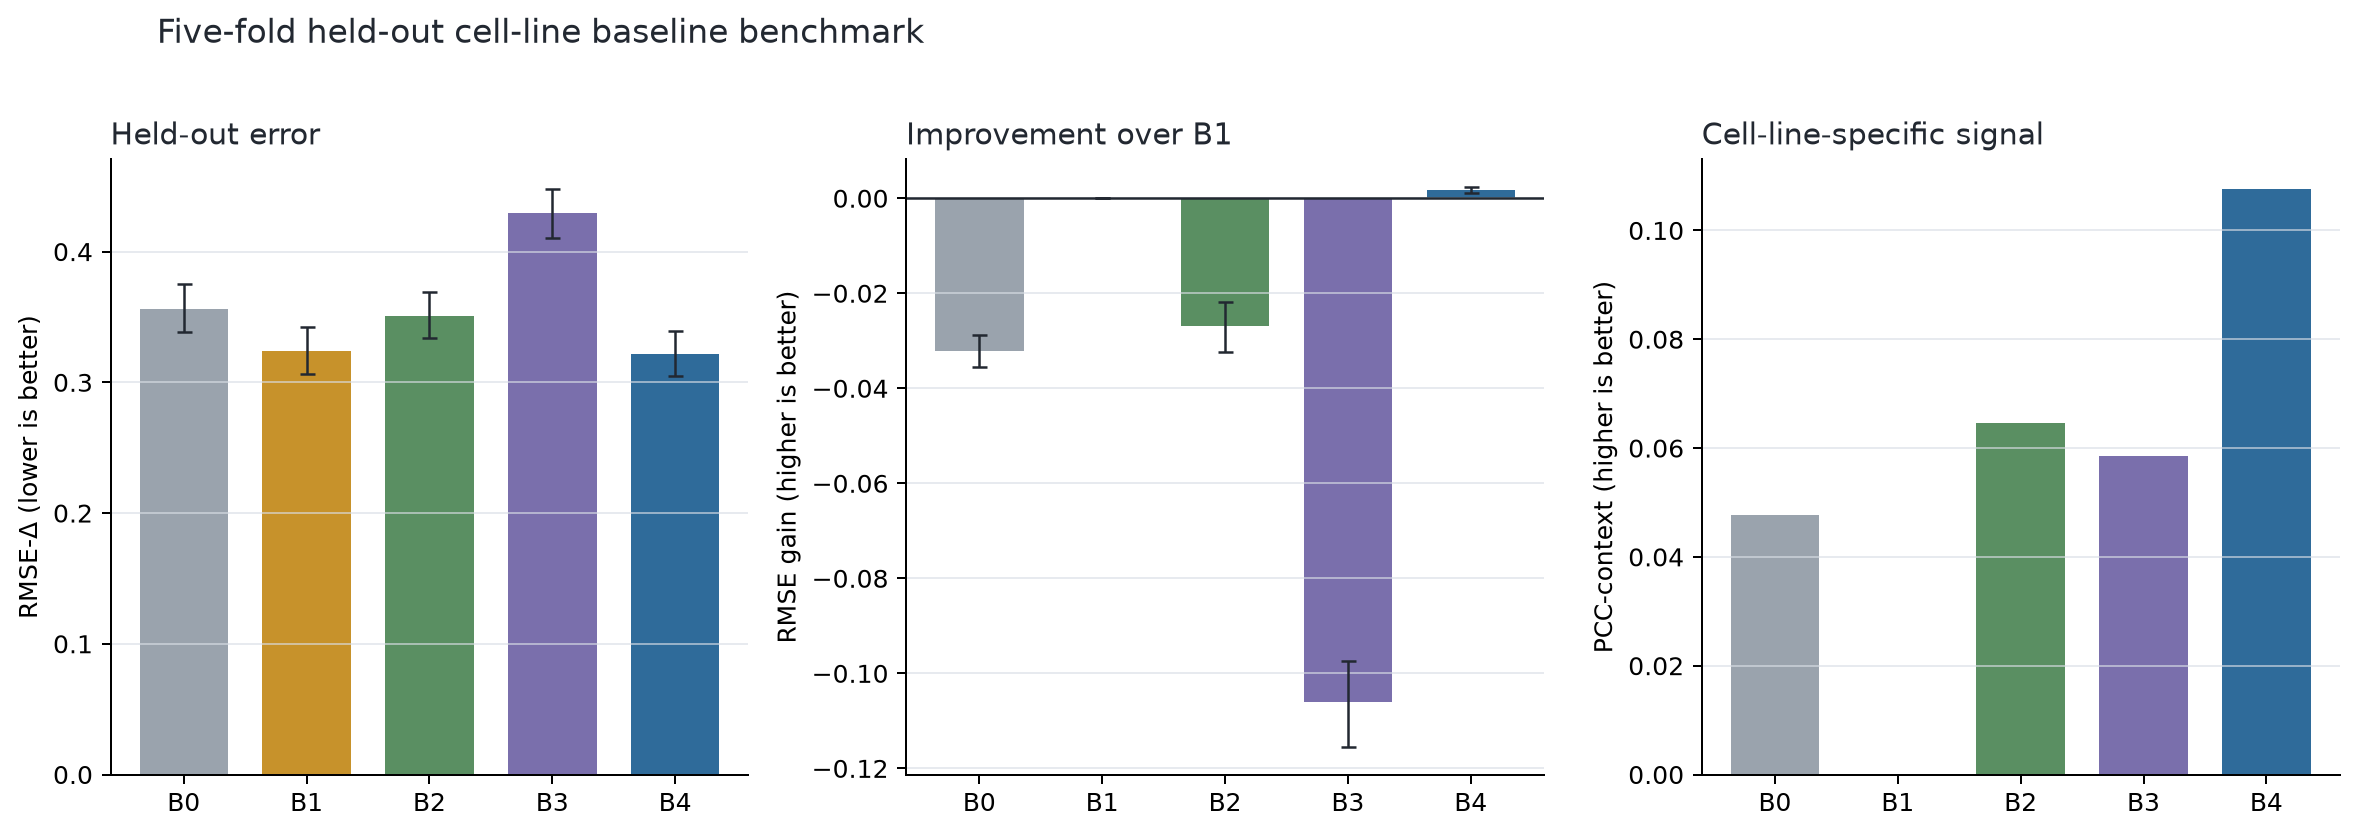

B4 relative RMSE improvement vs B1: 0.53%


In [3]:
display(Image(filename=str(root / "results/figures/baseline_performance.png")))
b1 = comparison.set_index("model").loc["B1"]
b4 = comparison.set_index("model").loc["B4"]
relative_gain = b4["rmse_gain_vs_b1_mean"] / b1["rmse_delta_mean"]
print(f"B4 relative RMSE improvement vs B1: {relative_gain:.2%}")


## Takeaways

- B1이 B0보다 낫다: 모든 세포주에 공유되는 trametinib 반응이 크다.
- B2와 B3는 B1보다 나쁘다: lineage 평균이나 단일 최근접 이웃은 반응
  이질성을 안정적으로 설명하지 못한다.
- B4는 B1을 근소하게 이기고 PCC-context는 `0.108`이다. baseline 전사 맥락의 추가 정보는
  검출되지만 현재 저복잡도 모델에서 실용적 크기는 작다.
- 다음 모델은 B4보다 복잡하게 만들기 전에, 평균 반응에 저차원 response component만 더하는
  CCLR이 이 작은 이득을 재현·확대하는지 같은 nested CV에서 확인해야 한다.